# GradCAM Analysis — Ordinal EfficientNet-B0

Visualizes which image regions the ordinal B0 model focuses on when classifying ISUP grades.
Combines GradCAM heatmaps with entropy analysis to understand confident vs uncertain predictions.

## 1. Imports

In [22]:
import os
import sys
import random
from typing import List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import albumentations as Albu

# Add repo root to path so utils can be imported
ROOT_DIR = os.path.abspath('../../../..')
sys.path.insert(0, ROOT_DIR)

from utils.dataset import PandasDataset
from utils.models import EfficientNetApi
from utils.metrics import calculate_entropy

# Reproducibility
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Configuration

In [23]:
DATA_DIR   = os.path.join(ROOT_DIR, 'repo', 'data')
IMAGES_DIR = os.path.join(ROOT_DIR, 'dataset', 'tiles')
MODEL_PATH = os.path.join(ROOT_DIR, 'repo', 'code', 'tests', 'baseline', 'models', 'b0-entropy-ordinal.pth')
OUTPUT_DIR = os.path.dirname(os.path.abspath('__file__'))  # same folder as this notebook

OUTPUT_CLASSES = 5  # ordinal thresholds for ISUP grades 0-5
DROPOUT_RATE   = 0.6
BATCH_SIZE     = 1  # must be 1 for GradCAM
NUM_WORKERS    = 2

print(f'Model : {MODEL_PATH}')
print(f'Data  : {DATA_DIR}')
print(f'Images: {IMAGES_DIR}')

Model : /home/woshington/Projects/Doutorado/repo/code/tests/baseline/models/b0-entropy-ordinal.pth
Data  : /home/woshington/Projects/Doutorado/repo/data
Images: /home/woshington/Projects/Doutorado/dataset/tiles


## 3. GradCAM Implementation

In [24]:
class GradCAM:
    """GradCAM for a model with ordinal sigmoid output."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients: torch.Tensor = None
        self.activations: torch.Tensor = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(
        self,
        input_tensor: torch.Tensor,
        target_class: int = None
    ) -> Tuple[np.ndarray, int, np.ndarray]:
        """Return (cam, predicted_grade, sigmoid_probs)."""
        self.model.eval()

        output = self.model(input_tensor)           # (1, 5)
        probs  = torch.sigmoid(output)              # (1, 5)
        prediction = probs.sum(1).detach().round()  # grade 0-5

        if target_class is None:
            target_class = int(prediction.item())

        self.model.zero_grad()

        # Backprop through the ordinal threshold at target_class
        idx = min(target_class, output.shape[1] - 1)
        output[0, idx].backward()

        # Global-average-pool the gradients then weight activations
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam).squeeze().cpu().numpy()  # (H, W)

        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, int(prediction.item()), probs.cpu().detach().numpy()[0]

    def generate_cam_with_entropy(
        self,
        input_tensor: torch.Tensor,
        target_class: int = None
    ) -> Tuple[np.ndarray, int, np.ndarray, float]:
        """Return (cam, predicted_grade, sigmoid_probs, entropy)."""
        cam, prediction, probs = self.generate_cam(input_tensor, target_class)
        probs_tensor = torch.tensor(probs).unsqueeze(0)
        entropy = calculate_entropy(probs_tensor).item()
        return cam, prediction, probs, entropy

## 4. Visualization Helpers

In [25]:
def apply_colormap_on_image(
    org_img: np.ndarray,
    activation_map: np.ndarray,
    colormap=cv2.COLORMAP_JET,
    alpha: float = 0.5
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (overlay, heatmap_rgb) both as uint8."""
    activation_map = cv2.resize(activation_map, (org_img.shape[1], org_img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * activation_map), colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    if org_img.dtype != np.uint8:
        org_img = np.uint8(org_img)

    overlay = np.uint8(heatmap * alpha + org_img * (1 - alpha))
    return overlay, heatmap


def visualize_gradcam(
    image: np.ndarray,
    cam: np.ndarray,
    prediction: int,
    true_label: int,
    probs: np.ndarray,
    entropy: float,
    image_id: str,
    save_path: str = None
):
    """Three-panel figure: original | heatmap | overlay."""
    overlay, heatmap = apply_colormap_on_image(image, cam)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(image);  axes[0].set_title('Original',       fontsize=13, fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(heatmap); axes[1].set_title('GradCAM Heatmap', fontsize=13, fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(overlay); axes[2].set_title('GradCAM Overlay', fontsize=13, fontweight='bold'); axes[2].axis('off')

    mark = '✓' if prediction == true_label else '✗'
    probs_str = ' '.join(f'{p:.2f}' for p in probs)
    fig.suptitle(
        f'Image: {image_id}\n'
        f'Pred: ISUP {prediction}  |  True: ISUP {true_label}  {mark}\n'
        f'Entropy: {entropy:.4f}   Probs: [{probs_str}]',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def visualize_gradcam_grid(
    images_data: list,
    nrows: int = 2,
    ncols: int = 3,
    title: str = '',
    save_path: str = None
):
    """Grid of GradCAM overlays.

    Each element of images_data: (image, cam, prediction, true_label, entropy, image_id)
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
    axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]

    for idx, (image, cam, pred, true_label, entropy, img_id) in enumerate(images_data[:nrows * ncols]):
        overlay, _ = apply_colormap_on_image(image, cam)
        mark = '✓' if pred == true_label else '✗'
        axes_flat[idx].imshow(overlay)
        axes_flat[idx].set_title(
            f'{img_id[:12]}…\nISUP Pred: {pred}  True: {true_label} {mark}\nH={entropy:.4f}',
            fontsize=9
        )
        axes_flat[idx].axis('off')

    for idx in range(len(images_data), len(axes_flat)):
        axes_flat[idx].axis('off')

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 5. Load Model

In [26]:
backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=backbone, output_dimensions=OUTPUT_CLASSES, dropout_rate=DROPOUT_RATE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded successfully!')
print(f'Checkpoint: {os.path.basename(MODEL_PATH)}')

Model loaded successfully!
Checkpoint: b0-entropy-ordinal.pth


## 6. Load Data

In [27]:
df_test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
df_test = df_test[df_test["image_id"]=='b48211c0c0fba52fcc8d919d03ed005b']
print(f'Test samples: {len(df_test)}')
print(df_test['isup_grade'].value_counts().sort_index())

Test samples: 1
isup_grade
5    1
Name: count, dtype: int64


In [28]:
# No augmentation for GradCAM — keep images as-is
test_transforms = Albu.Compose([])
test_dataset = PandasDataset(IMAGES_DIR, df_test, transforms=test_transforms)

print(f'Dataset size: {len(test_dataset)}')

Dataset size: 1


## 7. Initialize GradCAM

Target layer: last convolutional block of EfficientNet-B0 features (320 → 1280 channels).

In [29]:
target_layer = model.model.features[-1]
print(f'Target layer:\n{target_layer}')

gradcam = GradCAM(model, target_layer)

Target layer:
Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


## 8. Single-Image Example

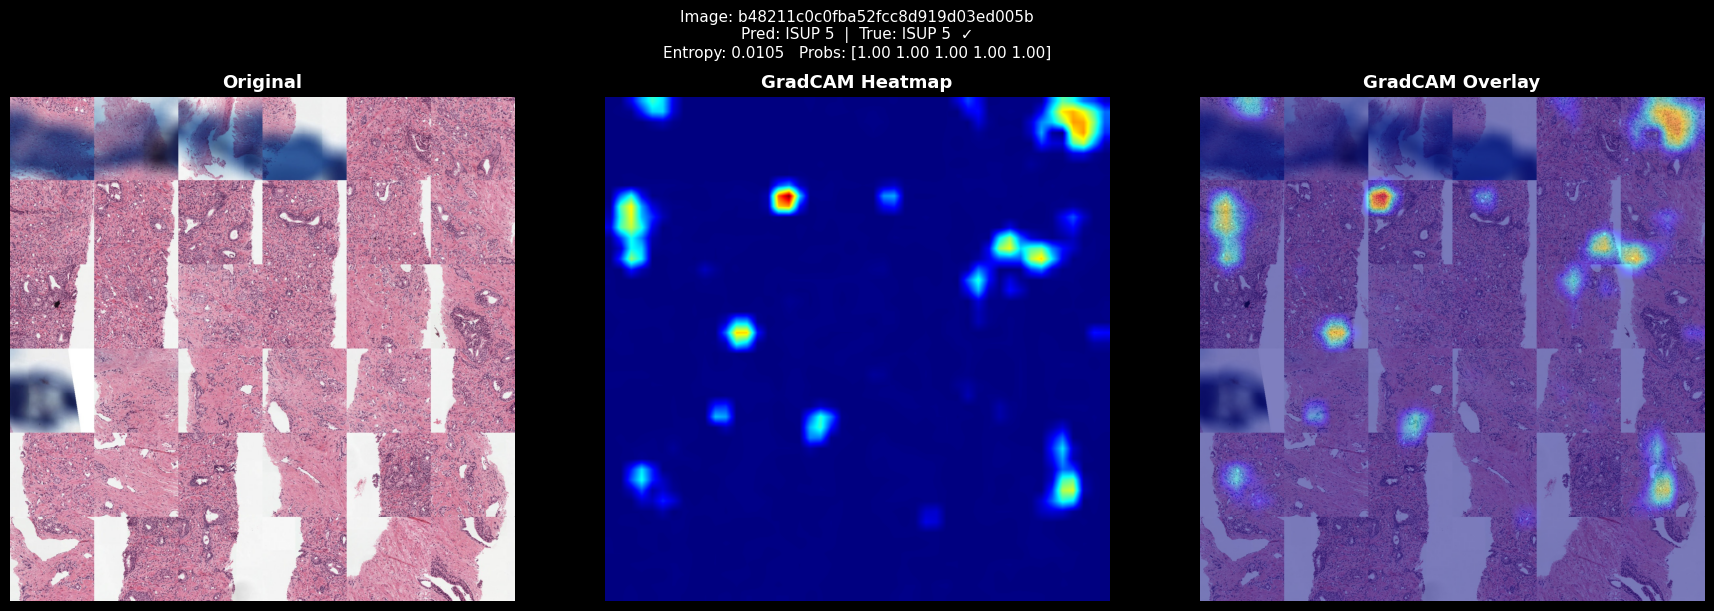

In [30]:
sample_idx = random.randint(0, len(test_dataset) - 1)
image_tensor, label_tensor, image_id = test_dataset[sample_idx]
true_label = int(label_tensor.sum().item())

input_tensor = image_tensor.unsqueeze(0).to(device)
cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)

image_np = (image_tensor.permute(1, 2, 0).cpu().numpy()).astype(np.uint8)

visualize_gradcam(
    image_np, cam, prediction, true_label, probs, entropy, image_id,
    save_path=os.path.join(OUTPUT_DIR, f'gradcam_single_{image_id}.png')
)

## 9. Compute Entropy for All Test Samples

In [31]:
# all_entropies    = []
# all_predictions  = []
# all_true_labels  = []
# all_image_ids    = []
#
# print('Computing predictions and entropy for all test samples...')
#
# with torch.no_grad():
#     for image_tensor, label_tensor, image_id in test_dataset:
#         inp = image_tensor.unsqueeze(0).to(device)
#         output = model(inp)
#         probs = torch.sigmoid(output)
#
#         all_predictions.append(int(probs.sum(1).detach().round().item()))
#         all_true_labels.append(int(label_tensor.sum().item()))
#         all_entropies.append(calculate_entropy(probs).item())
#         all_image_ids.append(image_id)
#
# results_df = pd.DataFrame({
#     'image_id'  : all_image_ids,
#     'entropy'   : all_entropies,
#     'prediction': all_predictions,
#     'true_label': all_true_labels,
# })
# results_df['correct'] = results_df['prediction'] == results_df['true_label']
#
# print(f'\nAccuracy: {results_df["correct"].mean():.4f}')
# print('\nEntropy statistics:')
# print(results_df['entropy'].describe())

## 10. Entropy Distribution

In [32]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#
# # Overall entropy distribution
# axes[0].hist(results_df['entropy'].dropna(), bins=50, edgecolor='black', alpha=0.7)
# axes[0].axvline(results_df['entropy'].median(), color='red', linestyle='--', label='Median')
# axes[0].set_xlabel('Entropy', fontsize=12)
# axes[0].set_ylabel('Count',   fontsize=12)
# axes[0].set_title('Prediction Entropy Distribution', fontsize=14, fontweight='bold')
# axes[0].legend(); axes[0].grid(alpha=0.3)
#
# # Entropy by correctness
# correct_h   = results_df[results_df['correct']]['entropy'].dropna()
# incorrect_h = results_df[~results_df['correct']]['entropy'].dropna()
# axes[1].hist([correct_h, incorrect_h], bins=30, label=['Correct', 'Incorrect'],
#              edgecolor='black', alpha=0.7)
# axes[1].set_xlabel('Entropy', fontsize=12)
# axes[1].set_ylabel('Count',   fontsize=12)
# axes[1].set_title('Entropy by Prediction Correctness', fontsize=14, fontweight='bold')
# axes[1].legend(); axes[1].grid(alpha=0.3)
#
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'entropy_distribution.png'), dpi=150, bbox_inches='tight')
# plt.show()
#
# print(f'Mean entropy  — correct  : {correct_h.mean():.4f}')
# print(f'Mean entropy  — incorrect: {incorrect_h.mean():.4f}')

## 11. GradCAM — Low vs High Entropy

In [33]:
# results_sorted = results_df.sort_values('entropy')
# low_entropy_rows  = results_sorted.dropna(subset=['entropy']).head(6)
# high_entropy_rows = results_sorted.dropna(subset=['entropy']).tail(6)
#
# print('Low entropy (confident):')
# print(low_entropy_rows[['image_id', 'entropy', 'prediction', 'true_label', 'correct']])
# print('\nHigh entropy (uncertain):')
# print(high_entropy_rows[['image_id', 'entropy', 'prediction', 'true_label', 'correct']])

In [34]:
# def collect_gradcam_data(rows: pd.DataFrame) -> list:
#     data = []
#     for _, row in rows.iterrows():
#         idx = all_image_ids.index(row['image_id'])
#         image_tensor, label_tensor, img_id = test_dataset[idx]
#         true_label = int(label_tensor.sum().item())
#         inp = image_tensor.unsqueeze(0).to(device)
#         cam, pred, probs, ent = gradcam.generate_cam_with_entropy(inp)
#         image_np = (image_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
#         data.append((image_np, cam, pred, true_label, ent, img_id))
#     return data
#
#
# low_entropy_data  = collect_gradcam_data(low_entropy_rows)
# high_entropy_data = collect_gradcam_data(high_entropy_rows)
#
# visualize_gradcam_grid(
#     low_entropy_data, nrows=2, ncols=3,
#     title='Low Entropy — Confident Predictions',
#     save_path=os.path.join(OUTPUT_DIR, 'gradcam_low_entropy.png')
# )
#
# visualize_gradcam_grid(
#     high_entropy_data, nrows=2, ncols=3,
#     title='High Entropy — Uncertain Predictions',
#     save_path=os.path.join(OUTPUT_DIR, 'gradcam_high_entropy.png')
# )

## 12. GradCAM — Correct vs Incorrect Predictions

In [35]:
# n = 6
# correct_rows   = results_df[results_df['correct']].sample(n=n, random_state=seed)
# incorrect_rows = results_df[~results_df['correct']].sample(n=min(n, (~results_df['correct']).sum()), random_state=seed)
#
# correct_data   = collect_gradcam_data(correct_rows)
# incorrect_data = collect_gradcam_data(incorrect_rows)
#
# visualize_gradcam_grid(
#     correct_data, nrows=2, ncols=3,
#     title='Correct Predictions',
#     save_path=os.path.join(OUTPUT_DIR, 'gradcam_correct.png')
# )
#
# visualize_gradcam_grid(
#     incorrect_data, nrows=2, ncols=3,
#     title='Incorrect Predictions',
#     save_path=os.path.join(OUTPUT_DIR, 'gradcam_incorrect.png')
# )

## 13. GradCAM per ISUP Grade

Select representative samples from each grade class.

In [36]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# axes_flat = axes.flatten()
#
# for grade in range(6):
#     grade_rows = results_df[results_df['true_label'] == grade]
#     if grade_rows.empty:
#         axes_flat[grade].axis('off')
#         continue
#
#     # Pick the sample with lowest entropy for this grade (most confident)
#     row = grade_rows.sort_values('entropy').iloc[0]
#     idx = all_image_ids.index(row['image_id'])
#     image_tensor, label_tensor, img_id = test_dataset[idx]
#     inp = image_tensor.unsqueeze(0).to(device)
#     cam, pred, probs, ent = gradcam.generate_cam_with_entropy(inp)
#
#     image_np = (image_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
#     overlay, _ = apply_colormap_on_image(image_np, cam)
#
#     mark = '✓' if pred == grade else '✗'
#     axes_flat[grade].imshow(overlay)
#     axes_flat[grade].set_title(
#         f'ISUP Grade {grade}\nPred: {pred}  {mark}   H={ent:.4f}',
#         fontsize=11
#     )
#     axes_flat[grade].axis('off')
#
# fig.suptitle('Most Confident GradCAM per ISUP Grade', fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam_per_grade.png'), dpi=150, bbox_inches='tight')
# plt.show()

## 14. Save Results

In [37]:
# out_csv = os.path.join(OUTPUT_DIR, 'ordinal_b0_gradcam_results.csv')
# results_df.to_csv(out_csv, index=False)
# print(f'Results saved to {out_csv}')
#
# print('\n=== Summary ===')
# print(f'Total samples   : {len(results_df)}')
# print(f'Accuracy        : {results_df["correct"].mean():.4f}')
# print(f'Mean entropy    : {results_df["entropy"].mean():.4f}')
# print(f'Median entropy  : {results_df["entropy"].median():.4f}')
# print(f'Entropy correct : {results_df[results_df["correct"]]["entropy"].mean():.4f}')
# print(f'Entropy incorrect: {results_df[~results_df["correct"]]["entropy"].mean():.4f}')